# 🕵️‍♂️ Detección de Fraude con Modelos Ocultos de Markov (HMM)

Este Jupyter Notebook implementa un sistema para la detección de fraudes en transacciones financieras utilizando un **Modelo Oculto de Markov (HMM)** y el **Algoritmo de Viterbi**.

> 🤖 **Nota:** Este código fue generado utilizando **Gemini 3.1 Pro**.

## 1. Importación de Librerías
Comenzamos importando las librerías necesarias para el análisis numérico, manipulación de datos y visualización.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random

# Configuración de estilo para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Implementación del Modelo HMM
Se define la clase `FraudDetectionHMM` que contiene:
- **Estados ocultos:** Transacción Legítima, Sospechosa y Fraudulenta.
- **Observaciones:** Monto Bajo, Medio y Alto.
- **Matrices:** Transición, Emisión y Distribución Inicial.
- **Simulación:** Generación de una secuencia de estados, observaciones y montos en dólares.
- **Algoritmo de Viterbi:** Para decodificar la secuencia más probable de estados ocultos dados los montos observados.
- **Scoring de Riesgo:** Calcula un score (0-100) en base al estado inferido y el monto de la transacción.

In [2]:
class FraudDetectionHMM:
    def __init__(self):
        # Definición de estados y observaciones
        self.states = ['Transacción Legítima', 'Transacción Sospechosa', 'Transacción Fraudulenta']
        self.observations = ['Monto Bajo', 'Monto Medio', 'Monto Alto']
        
        # Distribución Inicial
        self.start_prob = np.array([0.7, 0.2, 0.1])
        
        # Matriz de Transición
        self.trans_mat = np.array([
            [0.8, 0.15, 0.05], # Legítima
            [0.4, 0.4,  0.2 ], # Sospechosa
            [0.1, 0.3,  0.6 ]  # Fraudulenta
        ])
        
        # Matriz de Emisión
        self.emiss_mat = np.array([
            [0.6, 0.3, 0.1], # Legítima
            [0.3, 0.4, 0.3], # Sospechosa
            [0.1, 0.3, 0.6]  # Fraudulenta
        ])

    def generate_amount(self, observation):
        """Genera un monto real en dólares según la categoría observada."""
        if observation == 'Monto Bajo':
            return random.uniform(10, 100)
        elif observation == 'Monto Medio':
            return random.uniform(100, 1000)
        elif observation == 'Monto Alto':
            return random.uniform(1000, 10000)
            
    def simulate(self, n_steps=50):
        """Simula transacciones según las probabilidades del HMM."""
        actual_states = []
        observations = []
        amounts = []
        
        # Estado inicial
        current_state_idx = np.random.choice(3, p=self.start_prob)
        actual_states.append(self.states[current_state_idx])
        
        # Observación inicial
        obs_idx = np.random.choice(3, p=self.emiss_mat[current_state_idx])
        obs_name = self.observations[obs_idx]
        observations.append(obs_name)
        amounts.append(self.generate_amount(obs_name))
        
        for _ in range(n_steps - 1):
            # Siguiente estado
            current_state_idx = np.random.choice(3, p=self.trans_mat[current_state_idx])
            actual_states.append(self.states[current_state_idx])
            
            # Siguiente observación
            obs_idx = np.random.choice(3, p=self.emiss_mat[current_state_idx])
            obs_name = self.observations[obs_idx]
            observations.append(obs_name)
            amounts.append(self.generate_amount(obs_name))
            
        return actual_states, observations, amounts

    def viterbi(self, observations):
        """Infiere la secuencia más probable de estados usando el Algoritmo de Viterbi."""
        n_obs = len(observations)
        n_states = len(self.states)
        
        # Mapear observaciones a índices
        obs_indices = [self.observations.index(o) for o in observations]
        
        # Matrices de Viterbi (probabilidades y caminos)
        v = np.zeros((n_states, n_obs))
        path = np.zeros((n_states, n_obs), dtype=int)
        
        # Caso base (t=0)
        v[:, 0] = self.start_prob * self.emiss_mat[:, obs_indices[0]]
        
        # Paso recursivo
        for t in range(1, n_obs):
            for s in range(n_states):
                prob = v[:, t-1] * self.trans_mat[:, s] * self.emiss_mat[s, obs_indices[t]]
                v[s, t] = np.max(prob)
                path[s, t] = np.argmax(prob)
                
        # Backtracking para encontrar el mejor camino
        best_path = np.zeros(n_obs, dtype=int)
        best_path[-1] = np.argmax(v[:, -1])
        for t in range(n_obs - 2, -1, -1):
            best_path[t] = path[best_path[t+1], t+1]
            
        inferred_states = [self.states[i] for i in best_path]
        return inferred_states

    def calculate_risk_score(self, amount, inferred_state):
        """Calcula un score de riesgo del 0 al 100 basado en el estado y monto."""
        base_score = {'Transacción Legítima': 10, 'Transacción Sospechosa': 50, 'Transacción Fraudulenta': 90}[inferred_state]
        
        # Factor agravante basado en el monto
        if amount > 5000:
            score = base_score + 10
        elif amount > 1000:
            score = base_score + 5
        else:
            score = base_score
            
        return min(max(score, 0), 100)

## 3. Análisis y Métricas de Seguridad
Generamos un DataFrame con los resultados y calculamos las métricas clave para el equipo de seguridad.

In [3]:
def analyze_results(hmm, actual_states, inferred_states, amounts):
    """Genera métricas de evaluación del modelo y emite alertas."""
    df = pd.DataFrame({
        'Estado_Real': actual_states,
        'Estado_Inferido': inferred_states,
        'Monto': amounts
    })
    
    # Calcular Score de Riesgo y Alertas (>80 es fraude/crítico)
    df['Riesgo'] = df.apply(lambda row: hmm.calculate_risk_score(row['Monto'], row['Estado_Inferido']), axis=1)
    df['Alerta'] = df['Riesgo'] >= 80
    
    # --- CÁLCULO DE MÉTRICAS ---
    
    # 1. Tasa de fraude detectado (Recall de la clase Fraudulenta)
    actual_frauds = df[df['Estado_Real'] == 'Transacción Fraudulenta']
    if len(actual_frauds) > 0:
        detected_frauds = actual_frauds[actual_frauds['Estado_Inferido'] == 'Transacción Fraudulenta']
        fraud_detection_rate = len(detected_frauds) / len(actual_frauds)
    else:
        fraud_detection_rate = 1.0 
        
    # 2. Falsos positivos (Legítimas marcadas como Sospechosas o Fraudulentas)
    actual_legit = df[df['Estado_Real'] == 'Transacción Legítima']
    false_positives = actual_legit[actual_legit['Estado_Inferido'] != 'Transacción Legítima']
    fp_rate = len(false_positives) / len(actual_legit) if len(actual_legit) > 0 else 0
    
    # 3. Monto total en riesgo
    risk_amount = df[df['Estado_Inferido'].isin(['Transacción Fraudulenta', 'Transacción Sospechosa'])]['Monto'].sum()
    
    # 4. Tiempo promedio hasta detectar fraude
    fraud_indices = df.index[df['Estado_Inferido'] == 'Transacción Fraudulenta'].tolist()
    if len(fraud_indices) > 1:
        avg_time = sum([fraud_indices[i] - fraud_indices[i-1] for i in range(1, len(fraud_indices))]) / (len(fraud_indices) - 1)
        avg_time_str = f"{avg_time:.1f} transacciones"
    elif len(fraud_indices) == 1:
        avg_time_str = f"{fraud_indices[0]} transacciones desde inicio"
    else:
        avg_time_str = "Sin fraudes detectados"
        
    metrics = {
        'Tasa de Detección de Fraude': f"{fraud_detection_rate:.1%}",
        'Tasa de Falsos Positivos': f"{fp_rate:.1%}",
        'Monto Total en Riesgo': f"${risk_amount:,.2f}",
        'Tiempo Promedio para Detectar Fraude': avg_time_str
    }
    
    return df, metrics

## 4. Dashboard de Monitoreo
Función para visualizar los resultados en un dashboard interactivo utilizando `matplotlib` y `seaborn`.

In [4]:
def plot_dashboard(df, metrics):
    """Dibuja el dashboard con múltiples visualizaciones."""
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(3, 2)
    
    ax1 = fig.add_subplot(gs[0, :])
    ax2 = fig.add_subplot(gs[1, :])
    ax3 = fig.add_subplot(gs[2, 0])
    ax4 = fig.add_subplot(gs[2, 1])
    
    colors = {'Transacción Legítima': '#2ecc71', 'Transacción Sospechosa': '#f1c40f', 'Transacción Fraudulenta': '#e74c3c'}
    
    # --- 1. Timeline de transacciones ---
    c_real = [colors[s] for s in df['Estado_Real']]
    c_inf = [colors[s] for s in df['Estado_Inferido']]
    x = np.arange(len(df))
    
    ax1.scatter(x, [1.5]*len(df), c=c_real, s=150, marker='s', edgecolors='black', linewidth=0.5, label='Real')
    ax1.scatter(x, [0.5]*len(df), c=c_inf, s=150, marker='o', edgecolors='black', linewidth=0.5, label='Inferido')
    ax1.set_yticks([0.5, 1.5])
    ax1.set_yticklabels(['Viterbi (Inferido)', 'Sistema (Real)'], fontsize=12, fontweight='bold')
    ax1.set_title('Timeline de Transacciones (Cuadrado: Real, Círculo: Inferido)', fontsize=14, pad=15)
    ax1.set_ylim(0, 2)
    
    # Destacar Alertas de Fraude
    alert_idx = df.index[df['Alerta']].tolist()
    for i in alert_idx:
        ax1.axvline(x=i, color='red', linestyle='--', alpha=0.4)
        
    # --- 2. Gráfico de montos ---
    sns.lineplot(data=df, x=df.index, y='Monto', ax=ax2, color='#3498db', marker='o', linewidth=2)
    ax2.set_title('Montos de Transacciones con Alertas Destacadas', fontsize=14)
    ax2.set_ylabel('Monto en USD ($)', fontsize=12)
    ax2.set_xlabel('ID de Transacción', fontsize=12)
    
    for i in alert_idx:
        ax2.scatter(i, df.loc[i, 'Monto'], color='red', s=250, zorder=5, marker='*', edgecolor='black')
        
    # --- 3. Distribución de Estados (Inferidos) ---
    state_counts = df['Estado_Inferido'].value_counts()
    ax3.pie(state_counts, labels=state_counts.index, autopct='%1.1f%%', startangle=90,
            colors=[colors.get(x) for x in state_counts.index],
            wedgeprops={'edgecolor': 'black'})
    ax3.set_title('Distribución de Tipos de Transacción', fontsize=14)
    
    # --- 4. Distribución de Scoring de Riesgo ---
    sns.histplot(data=df, x='Riesgo', bins=15, ax=ax4, color='#9b59b6', kde=True)
    ax4.set_title('Score de Riesgo (0-100)', fontsize=14)
    ax4.axvline(x=80, color='red', linestyle='dashed', linewidth=2, label='Umbral Crítico (80)')
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Imprimir Alertas y Patrones
    print("\n" + "="*50)
    print(" 🚨 ALERTAS AUTOMÁTICAS DE FRAUDE")
    print("="*50)
    if not alert_idx:
        print("No se detectaron transacciones de alto riesgo.")
    for idx in alert_idx:
        print(f"[ALERTA] Transacción #{idx} | Monto: ${df.loc[idx, 'Monto']:.2f} | Score: {df.loc[idx, 'Riesgo']} | Estado: {df.loc[idx, 'Estado_Inferido']}")
        
    print("\n" + "="*50)
    print(" 📊 MÉTRICAS DE SEGURIDAD FINANCIERA")
    print("="*50)
    for k, v in metrics.items():
        print(f"{k:<40}: {v}")

## 5. Simulación Principal
Instanciamos el modelo HMM, simulamos 50 transacciones, ejecutamos Viterbi y generamos el reporte de seguridad.

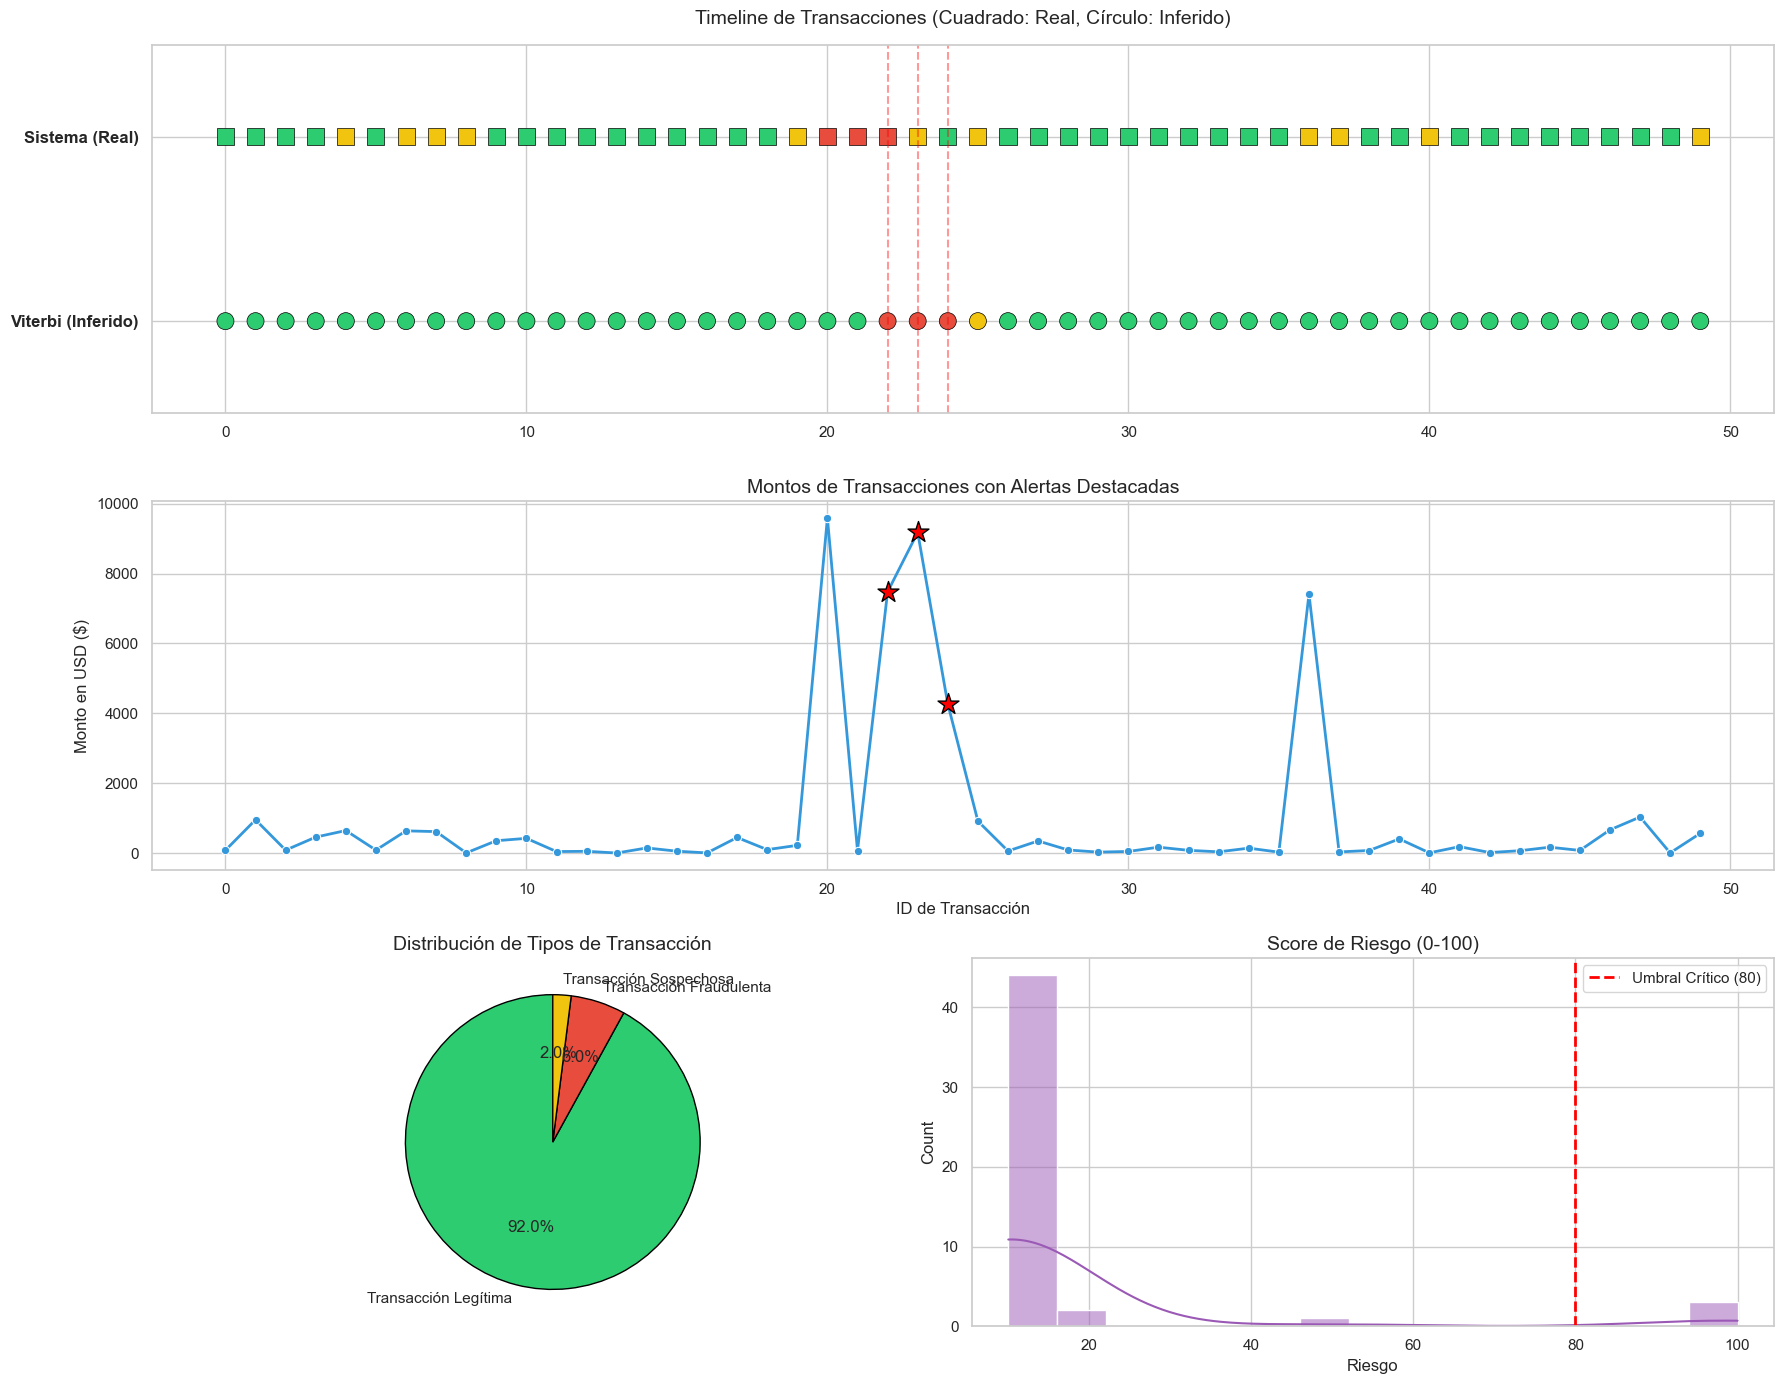


 🚨 ALERTAS AUTOMÁTICAS DE FRAUDE
[ALERTA] Transacción #22 | Monto: $7476.35 | Score: 100 | Estado: Transacción Fraudulenta
[ALERTA] Transacción #23 | Monto: $9176.81 | Score: 100 | Estado: Transacción Fraudulenta
[ALERTA] Transacción #24 | Monto: $4272.95 | Score: 95 | Estado: Transacción Fraudulenta

 📊 MÉTRICAS DE SEGURIDAD FINANCIERA
Tasa de Detección de Fraude             : 33.3%
Tasa de Falsos Positivos                : 2.8%
Monto Total en Riesgo                   : $21,847.98
Tiempo Promedio para Detectar Fraude    : 1.0 transacciones


In [5]:
# 1. Inicializar el modelo
hmm = FraudDetectionHMM()

# 2. Simular 50 transacciones
actual_states, observations, amounts = hmm.simulate(n_steps=50)

# 3. Aplicar Algoritmo de Viterbi para inferencia de estados
inferred_states = hmm.viterbi(observations)

# 4. Analizar resultados y calcular métricas
df_results, metrics = analyze_results(hmm, actual_states, inferred_states, amounts)

# 5. Visualizar Dashboard y Alertas
plot_dashboard(df_results, metrics)